[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/aubreycoffey/single-cell-analysis-pipeline/blob/main/notebooks/04_trajectory_inference.ipynb)

# Notebook 4: Trajectory Inference

We use PAGA (partition-based graph abstraction) and diffusion pseudotime to model transitions between cell states — particularly the T cell compartment (naive → memory → effector).

## Google Drive setup

Mount Drive to persist data between notebook sessions. All `.h5ad` files will be saved to `MyDrive/scrnaseq-pbmc-pipeline-data/`.

In [1]:
from google.colab import drive
drive.mount('/content/drive')
import os
DATA_DIR = '/content/drive/MyDrive/scrnaseq-pbmc-pipeline-data'
os.makedirs(DATA_DIR, exist_ok=True)
print(f'Data directory: {DATA_DIR}')

Mounted at /content/drive
Data directory: /content/drive/MyDrive/scrnaseq-pbmc-pipeline-data


In [2]:
import sys
!{sys.executable} -m pip install -q scanpy leidenalg python-igraph

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 44.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 65.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 66.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 69.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 64.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.

In [3]:
import scanpy as sc
sc.settings.verbosity = 1
sc.settings.set_figure_params(dpi=100, facecolor='white')

/tmp/ipykernel_20045/1465342122.py:3: FutureWarning: Use `scanpy.set_figure_params` instead
  sc.settings.set_figure_params(dpi=100, facecolor='white')


In [4]:
adata = sc.read_h5ad(f'{DATA_DIR}/pbmc_de.h5ad')
print(adata)

AnnData object with n_obs × n_vars = 2638 × 1830
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'leiden', 'cell_type'
    var: 'gene_ids', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'cell_type_colors', 'dendrogram_cell_type', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'rank_genes_groups', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'


## 1. PAGA

PAGA computes a graph of cluster-to-cluster connectivity, weighted by statistical confidence. It gives a topology-level view of how cell populations relate to each other.

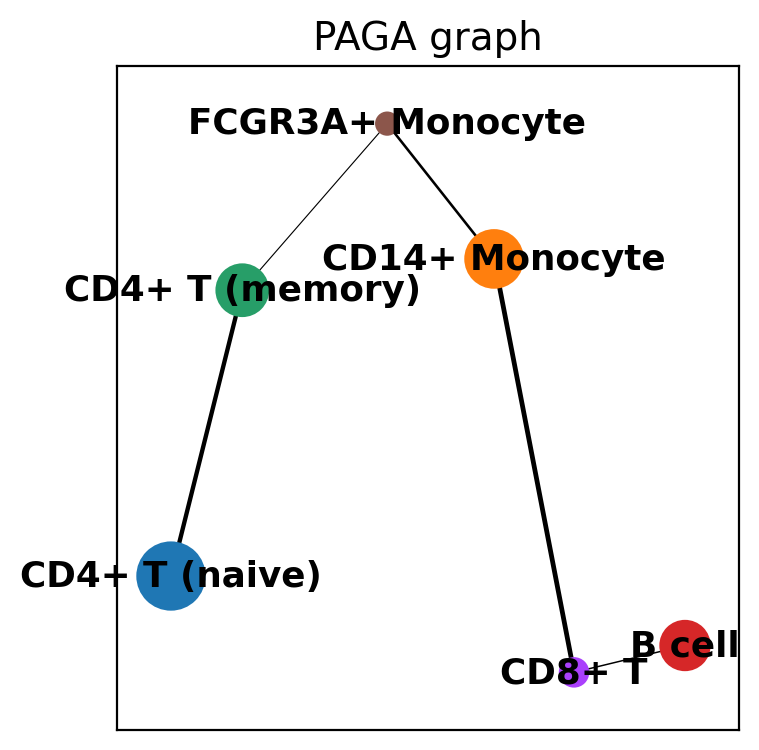

In [5]:
sc.tl.paga(adata, groups='cell_type')
sc.pl.paga(adata, threshold=0.03, title='PAGA graph', node_size_scale=2)

## 2. PAGA-initialized UMAP

Reinitializing UMAP using PAGA positions produces a layout that better reflects the underlying cell state topology.

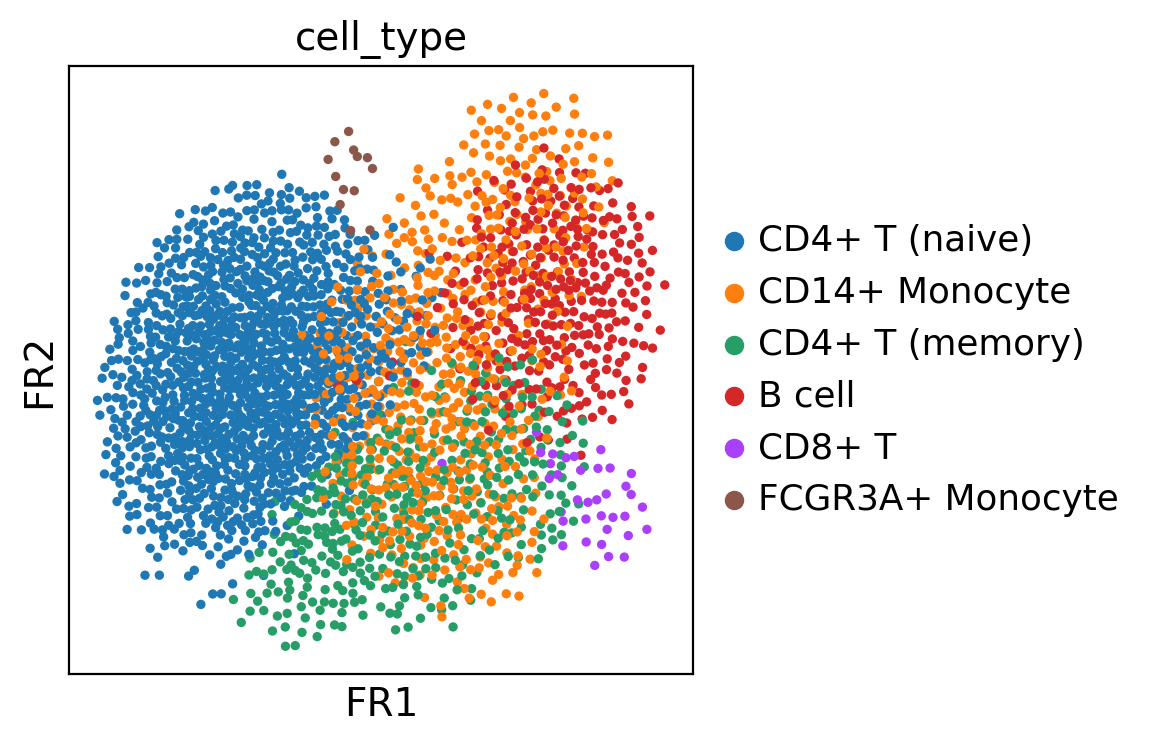

In [6]:
sc.tl.draw_graph(adata, init_pos='paga')
sc.pl.draw_graph(adata, color='cell_type', legend_loc='right margin')

## 3. Diffusion pseudotime

Diffusion pseudotime (DPT) assigns each cell a pseudotime value representing its progression along a differentiation trajectory. We root the trajectory at a naive CD4+ T cell (cell 0 from that cluster).

In [7]:
# Compute diffusion map
sc.tl.diffmap(adata)

# Set root: pick the first naive CD4+ T cell
root_idx = adata.obs.index[adata.obs['cell_type'] == 'CD4+ T (naive)'][0]
adata.uns['iroot'] = adata.obs_names.get_loc(root_idx)
print(f'Root cell index: {adata.uns["iroot"]}')

# Run DPT
sc.tl.dpt(adata)
print('Diffusion pseudotime computed.')

Root cell index: 0
Diffusion pseudotime computed.


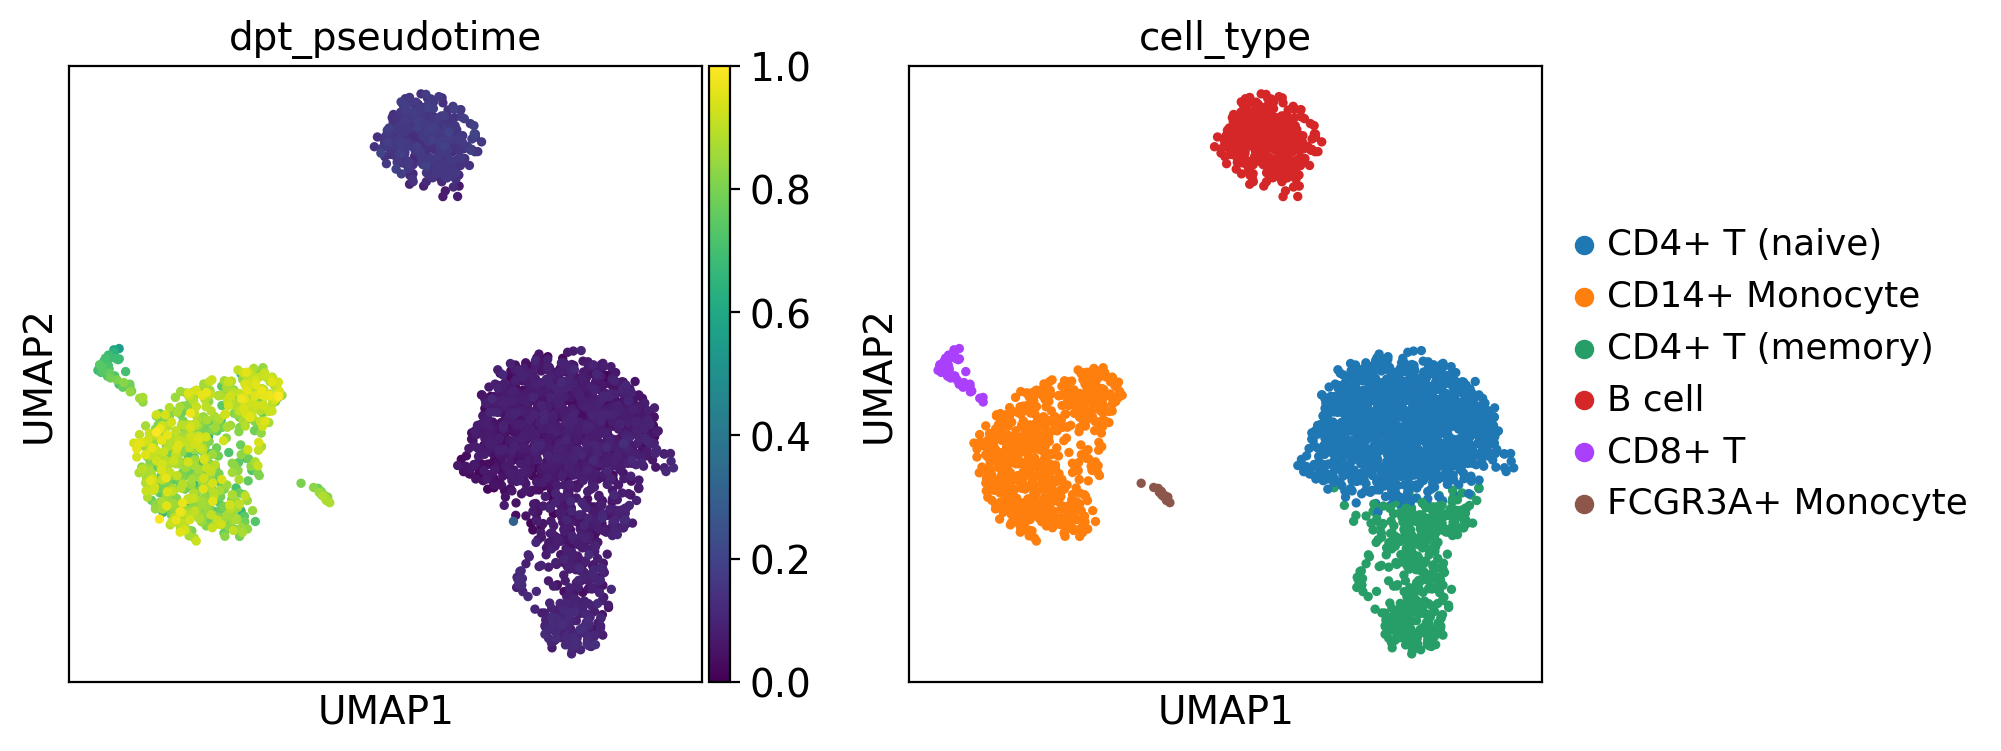

In [8]:
sc.pl.umap(adata, color=['dpt_pseudotime', 'cell_type'], ncols=2)

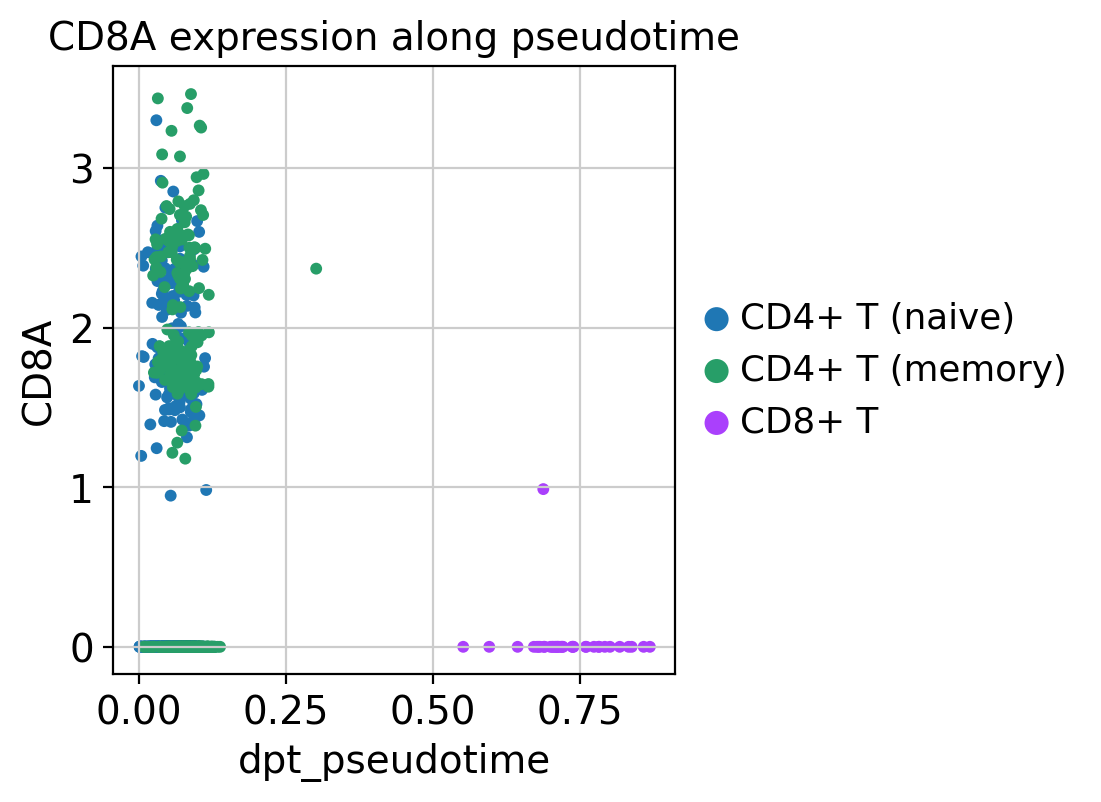

In [9]:
# Pseudotime along the T-cell axis
t_cell_types = ['CD4+ T (naive)', 'CD4+ T (memory)', 'CD8+ T']
t_cells = adata[adata.obs['cell_type'].isin(t_cell_types)].copy()

sc.pl.scatter(t_cells, x='dpt_pseudotime', y='CD8A', color='cell_type',
              title='CD8A expression along pseudotime')

### Interpretation

Cells with lower pseudotime values are positioned closer to the naive T cell root. Naive CD4+ T cells occupy early pseudotime, with memory and CD8+ T cells at later positions — consistent with known T cell differentiation biology.

In [10]:
adata.write(f'{DATA_DIR}/pbmc_trajectory.h5ad')
print('Saved to ../data/pbmc_trajectory.h5ad')

Saved to ../data/pbmc_trajectory.h5ad
